# Competitive-binding Kd models

This notebook demonstrates competitive-binding models: `comp_3st_specific`, `comp_3st_total`, `comp_4st_specific`, and `comp_4st_total`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import bindcurve as bc

rng = np.random.default_rng(123)

## Helper for synthetic competition data

In [2]:
def make_competition_data(model_name, params, compound_id='competitor_a'):
    model = bc.get_model(model_name)
    concentrations = np.logspace(-3, 2, 22)
    rows = []
    for experiment_id, scale in {'exp1': 0.95, 'exp2': 1.00, 'exp3': 1.05}.items():
        for concentration in concentrations:
            response = model.evaluate(np.array([concentration * scale]), **params)[0]
            for replicate_id in range(1, 4):
                rows.append({
                    'compound_id': compound_id,
                    'experiment_id': experiment_id,
                    'concentration': concentration,
                    'replicate_id': f'rep{replicate_id}',
                    'response': response + rng.normal(0, 0.75),
                })
    return bc.DoseResponseData.from_dataframe(pd.DataFrame(rows), concentration_unit='uM', response_unit='percent')

## Three-state specific competition

In [3]:
params_3st = {
    'ymin': 5.0, 'ymax': 95.0,
    'RT': 0.05, 'LsT': 0.005, 'Kds': 0.02,
    'Kd': 1.6,
}
data_3st = make_competition_data('comp_3st_specific', params_3st)
results_3st = bc.fit(
    data_3st,
    model='comp_3st_specific',
    fixed={'ymin': 5.0, 'ymax': 95.0, 'RT': 0.05, 'LsT': 0.005, 'Kds': 0.02},
)
results_3st.summary_to_dataframe()

,compound_id,parameter,n,mean,sd,sem,unit,summary_scale,geometric_mean,log10_mean,log10_sd
0,competitor_a,Kd,3,1.607583,7.374266e-02,4.257534e-02,uM,log10,1.606457,0.205869,0.019913
1,competitor_a,Kds,3,0.020000,0.000000e+00,0.000000e+00,uM,log10,0.020000,-1.698970,0.000000
2,competitor_a,LsT,3,0.005000,0.000000e+00,0.000000e+00,uM,log10,0.005000,-2.301030,0.000000
3,competitor_a,RT,3,0.050000,8.498375e-18,4.906539e-18,uM,log10,0.050000,-1.301030,0.000000
4,competitor_a,ymax,3,95.000000,0.000000e+00,0.000000e+00,percent,linear,NaN,NaN,NaN
5,competitor_a,ymin,3,5.000000,0.000000e+00,0.000000e+00,percent,linear,NaN,NaN,NaN


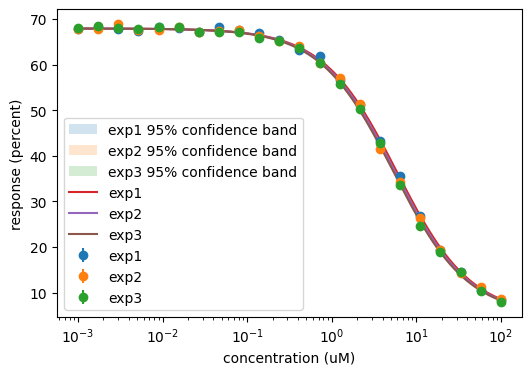

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
bc.plot_curves(data_3st, results_3st, ax=ax, confidence_band=True)
ax.legend()
plt.show()

## Three-state total competition

The total/nonspecific model uses dimensionless `N`.

In [5]:
params_3st_total = {
    'ymin': 4.0, 'ymax': 90.0,
    'RT': 0.05, 'LsT': 0.005, 'Kds': 0.02,
    'N': 0.35,
    'Kd': 2.4,
}
data_3st_total = make_competition_data('comp_3st_total', params_3st_total)
results_3st_total = bc.fit(
    data_3st_total,
    model='comp_3st_total',
    fixed={'ymin': 4.0, 'ymax': 90.0, 'RT': 0.05, 'LsT': 0.005, 'Kds': 0.02, 'N': 0.35},
)
results_3st_total.summary_to_dataframe()

,compound_id,parameter,n,mean,sd,sem,unit,summary_scale,geometric_mean,log10_mean,log10_sd
0,competitor_a,Kd,3,2.388654,1.340871e-01,7.741522e-02,uM,log10,2.386129,0.377694,0.024508
1,competitor_a,Kds,3,0.020000,0.000000e+00,0.000000e+00,uM,log10,0.020000,-1.698970,0.000000
2,competitor_a,LsT,3,0.005000,0.000000e+00,0.000000e+00,uM,log10,0.005000,-2.301030,0.000000
3,competitor_a,N,3,0.350000,6.798700e-17,3.925231e-17,NaN,linear,NaN,NaN,NaN
4,competitor_a,RT,3,0.050000,8.498375e-18,4.906539e-18,uM,log10,0.050000,-1.301030,0.000000
5,competitor_a,ymax,3,90.000000,0.000000e+00,0.000000e+00,percent,linear,NaN,NaN,NaN
6,competitor_a,ymin,3,4.000000,0.000000e+00,0.000000e+00,percent,linear,NaN,NaN,NaN


## Four-state specific competition

The four-state model adds `Kd3`, the affinity of labeled ligand to the receptor-competitor complex.

In [6]:
params_4st = {
    'ymin': 5.0, 'ymax': 95.0,
    'RT': 0.05, 'LsT': 0.005, 'Kds': 0.02,
    'Kd3': 0.5,
    'Kd': 1.6,
}
data_4st = make_competition_data('comp_4st_specific', params_4st)
results_4st = bc.fit(
    data_4st,
    model='comp_4st_specific',
    fixed={'ymin': 5.0, 'ymax': 95.0, 'RT': 0.05, 'LsT': 0.005, 'Kds': 0.02, 'Kd3': 0.5},
)
results_4st.summary_to_dataframe()

,compound_id,parameter,n,mean,sd,sem,unit,summary_scale,geometric_mean,log10_mean,log10_sd
0,competitor_a,Kd,3,1.60866,5.921194e-02,3.418603e-02,uM,log10,1.607941,0.20627,0.01587
1,competitor_a,Kd3,3,0.50000,0.000000e+00,0.000000e+00,uM,log10,0.500000,-0.30103,0.00000
2,competitor_a,Kds,3,0.02000,0.000000e+00,0.000000e+00,uM,log10,0.020000,-1.69897,0.00000
3,competitor_a,LsT,3,0.00500,0.000000e+00,0.000000e+00,uM,log10,0.005000,-2.30103,0.00000
4,competitor_a,RT,3,0.05000,8.498375e-18,4.906539e-18,uM,log10,0.050000,-1.30103,0.00000
5,competitor_a,ymax,3,95.00000,0.000000e+00,0.000000e+00,percent,linear,NaN,NaN,NaN
6,competitor_a,ymin,3,5.00000,0.000000e+00,0.000000e+00,percent,linear,NaN,NaN,NaN


## IC50-to-Kd conversion

Conversion is separate from fitting.

In [7]:
bc.convert_ic50_to_kd(
    model='cheng_prusoff',
    IC50=10.0,
    LsT=0.005,
    Kds=0.02,
    unit='uM',
)

IC50ConversionResult(compound_id=None, model='cheng_prusoff', IC50=10.0, Kd=8.0, lower_IC50=None, upper_IC50=None, lower_Kd=None, upper_Kd=None, unit='uM')